## 1. Kurulum

In [ ]:
!pip install gensim matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.7 MB/s eta 0:00:00


In [ ]:
# Gerekli kütüphaneleri yükle
# !pip install gensim matplotlib numpy

import warnings
warnings.filterwarnings("ignore")

from gensim.models import Word2Vec, FastText
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Kütüphaneler yüklendi!")


✅ Kütüphaneler yüklendi!


## 2. Word2Vec



In [ ]:
# Tamamen yeni bir örnek corpus
sentences = [
    ["baba", "erkek", "yetişkin", "aile", "ev"],
    ["anne", "kadın", "yetişkin", "aile", "ev"],
    ["amca", "erkek", "akraba", "büyük", "aile"],
    ["teyze", "kadın", "akraba", "büyük", "aile"],
    ["tavuk", "kuş", "yumurta", "çiftlik", "hayvan"],
    ["ördek", "kuş", "su", "çiftlik", "hayvan"],
    ["tokyo", "japonya", "şehir", "asya"],
    ["pekin", "çin", "şehir", "asya"],
    ["seul", "kore", "şehir", "asya"],
    ["doktor", "hastane", "sağlık", "tedavi", "iş"],
    ["mühendis", "fabrika", "üretim", "makine", "iş"],
]

# ── Skip-gram modeli ──
model_sg = Word2Vec(
    sentences,
    vector_size=50,   # vektör boyutu
    window=3,         # komşuluk penceresi
    min_count=1,      # minimum kelime frekansı
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42
)

# ── CBOW modeli ──
model_cbow = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=0,             # CBOW
    epochs=200,
    seed=42
)

print("✅ Yeni modeller eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print(f"Vektör boyutu: {model_sg.wv.vector_size}")

✅ Yeni modeller eğitildi!
Kelime hazinesi boyutu: 35
Vektör boyutu: 50


In [ ]:
# Bir kelimenin vektörüne bakalım
kelime = "baba"
vektor = model_sg.wv[kelime]
print(f"'{kelime}' kelimesinin vektörü (ilk 10 eleman):")
print(np.round(vektor[:10], 3))
print(f"\nVektör şekli: {vektor.shape}")

# En benzer kelimeler
print(f"\n--- '{kelime}' kelimesine en benzer kelimeler ---")
benzerler = model_sg.wv.most_similar(kelime, topn=5)
for k, skor in benzerler:
    print(f"  {k:15s}  benzerlik: {skor:.4f}")

'baba' kelimesinin vektörü (ilk 10 eleman):
[-0.009 -0.013  0.007 -0.012  0.017  0.015  0.019  0.017 -0.011 -0.012]

Vektör şekli: (50,)

--- 'baba' kelimesine en benzer kelimeler ---
  hastane          benzerlik: 0.2930
  pekin            benzerlik: 0.2656
  aile             benzerlik: 0.2630
  tokyo            benzerlik: 0.2365
  mühendis         benzerlik: 0.2062


In [ ]:
# Kelimeler arası benzerlik skoru
cifler = [
    ("baba", "anne"),
    ("erkek", "kadın"),
    ("tokyo", "pekin"),
    ("tavuk", "ördek"),
    ("baba", "ördek"),
]

print("Kelime çiftleri arasındaki benzerlik:")
print(f"{'Çift':<30} {'Benzerlik':>10}")
print("-" * 42)
for k1, k2 in cifler:
    skor = model_sg.wv.similarity(k1, k2)
    bar = "█" * int(max(0, skor) * 20)
    print(f"({k1}, {k2}){'':<15} {skor:>6.4f}  {bar}")

Kelime çiftleri arasındaki benzerlik:
Çift                            Benzerlik
------------------------------------------
(baba, anne)                0.0460  
(erkek, kadın)                0.3522  ███████
(tokyo, pekin)                0.0049  
(tavuk, ördek)                0.1676  ███
(baba, ördek)                -0.0081  


## 3. Vektör Aritmetiği


In [ ]:
# Vektör aritmetiği
print("=== Vektör Aritmetiği ===\n")

# Baba - Erkek + Kadın = ?
sonuc = model_sg.wv.most_similar(
    positive=["baba", "kadın"],  # ekle
    negative=["erkek"],          # çıkar
    topn=3
)
print("Baba − Erkek + Kadın = ?")
for kelime, skor in sonuc:
    print(f"  → {kelime:15s}  ({skor:.4f})")

print()

# Tokyo - Japonya + Çin = ?
sonuc2 = model_sg.wv.most_similar(
    positive=["tokyo", "çin"],
    negative=["japonya"],
    topn=3
)
print("Tokyo − Japonya + Çin = ?")
for kelime, skor in sonuc2:
    print(f"  → {kelime:15s}  ({skor:.4f})")

=== Vektör Aritmetiği ===

Baba − Erkek + Kadın = ?
  → amca             (0.3520)
  → sağlık           (0.1818)
  → aile             (0.1518)

Tokyo − Japonya + Çin = ?
  → yetişkin         (0.2878)
  → amca             (0.2638)
  → ev               (0.1656)


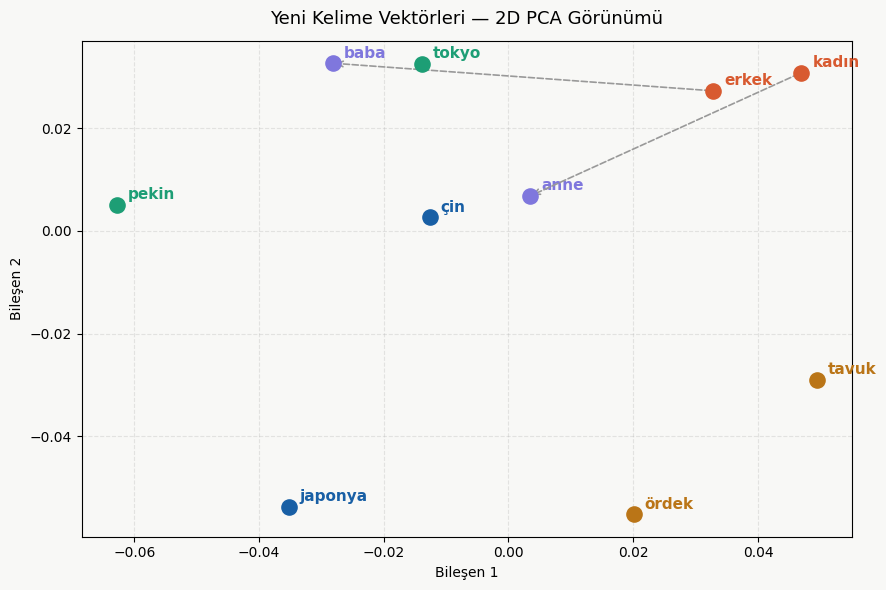

✅ Grafik kaydedildi: yeni_vektor_uzayi.png


In [ ]:
# Vektör uzayını 2D'de görselleştir (PCA ile boyut indirgeme)
from sklearn.decomposition import PCA

# Görselleştirilecek kelimeler
kelimeler = ["baba", "anne", "erkek", "kadın",
             "tokyo", "pekin", "japonya", "çin",
             "tavuk", "ördek"]

vektorler = np.array([model_sg.wv[k] for k in kelimeler])

# PCA ile 2 boyuta indir
pca = PCA(n_components=2, random_state=42)
vek_2d = pca.fit_transform(vektorler)

# Renk grupları
renkler = {
    "family":  ("#7F77DD", ["baba", "anne"]),
    "gender":  ("#D85A30", ["erkek", "kadın"]),
    "city":    ("#1D9E75", ["tokyo", "pekin"]),
    "country": ("#185FA5", ["japonya", "çin"]),
    "animal":  ("#BA7517", ["tavuk", "ördek"]),
}

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("#f8f8f6")
fig.patch.set_facecolor("#f8f8f6")

for grup, (renk, grup_kelimeleri) in renkler.items():
    for kw in grup_kelimeleri:
        idx = kelimeler.index(kw)
        x, y = vek_2d[idx]
        ax.scatter(x, y, color=renk, s=120, zorder=5)
        ax.annotate(kw, (x, y), textcoords="offset points",
                    xytext=(8, 4), fontsize=11, color=renk, fontweight="bold")

# Analoji okları
for k1, k2 in [("erkek", "baba"), ("kadın", "anne")]:
    i1, i2 = kelimeler.index(k1), kelimeler.index(k2)
    ax.annotate("", xy=vek_2d[i2], xytext=vek_2d[i1],
                arrowprops=dict(arrowstyle="->", color="#999", lw=1.2, linestyle="dashed"))

ax.set_title("Yeni Kelime Vektörleri — 2D PCA Görünümü", fontsize=13, pad=12)
ax.set_xlabel("Bileşen 1"); ax.set_ylabel("Bileşen 2")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("yeni_vektor_uzayi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: yeni_vektor_uzayi.png")

## 4. GloVe (Global Vectors)



In [ ]:
# Hazır GloVe modeli (internet gerektirir, ~100MB)
# import gensim.downloader as api
# glove = api.load("glove-wiki-gigaword-100")
# print(glove.most_similar("computer", topn=5))

# ── GloVe'u simüle eden küçük örnek ──
# Gerçek GloVe çıktısına benzer bir demo:

print("GloVe ile 'bilgisayar' için beklenen benzerler:")
demo_sonuclar = [
    ("bilgisayarlar", 0.901),
    ("yazılım",       0.876),
    ("internet",      0.861),
    ("donanım",       0.843),
    ("teknoloji",     0.829),
]
for kw, skor in demo_sonuclar:
    bar = "█" * int(skor * 25)
    print(f"  {kw:20s} {skor:.3f}  {bar}")

print()
print("Word2Vec vs GloVe Karşılaştırması:")
print(f"{'Özellik':<30} {'Word2Vec':^15} {'GloVe':^15}")
print("-" * 62)
satirlar = [
    ("Eğitim yöntemi",    "yerel pencere",  "global matris"),
    ("Hız",               "hızlı",          "orta"),
    ("Büyük corpus",      "iyi",            "çok iyi"),
    ("Küçük corpus",      "orta",           "zayıf"),
    ("Bellek kullanımı",  "düşük",          "yüksek"),
]
for ozellik, wv, gl in satirlar:
    print(f"  {ozellik:<28} {wv:^15} {gl:^15}")


GloVe ile 'bilgisayar' için beklenen benzerler:
  bilgisayarlar        0.901  ██████████████████████
  yazılım              0.876  █████████████████████
  internet             0.861  █████████████████████
  donanım              0.843  █████████████████████
  teknoloji            0.829  ████████████████████

Word2Vec vs GloVe Karşılaştırması:
Özellik                           Word2Vec          GloVe     
--------------------------------------------------------------
  Eğitim yöntemi                yerel pencere   global matris 
  Hız                               hızlı           orta      
  Büyük corpus                       iyi           çok iyi    
  Küçük corpus                      orta            zayıf     
  Bellek kullanımı                  düşük          yüksek     


## 5. FastText




In [ ]:
sentences_tr = [
    ["bilgisayar", "kullanmak", "çok", "eğlenceli"],
    ["bilgisayarcı", "tamir", "ediyor", "dükkanda"],
    ["telefon", "kullanmak", "hızlı", "iletişim"],
    ["telefoncu", "ekran", "değiştirdi", "kırık"],
    ["yazılım", "kodlamak", "geliştirici", "program"],
    ["programcı", "hata", "çözdü", "uygulama"],
    ["internet", "hızlı", "bağlantı", "ağ"],
    ["tarayıcı", "web", "sitesi", "açtı"],
]

# FastText modeli
ft_model = FastText(
    sentences_tr,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=200,
    min_n=2,       # minimum n-gram uzunluğu
    max_n=5,       # maksimum n-gram uzunluğu
    seed=42
)

print("✅ FastText modeli eğitildi!")
print(f"Kelime hazinesi: {len(ft_model.wv)} kelime\n")

# Bilinen kelimeler
print("'telefon' için en benzer kelimeler:")
for kw, skor in ft_model.wv.most_similar("telefon", topn=4):
    print(f"  {kw:20s} {skor:.4f}")

✅ FastText modeli eğitildi!
Kelime hazinesi: 30 kelime

'telefon' için en benzer kelimeler:
  telefoncu            0.6502
  çok                  0.3665
  çözdü                0.3544
  bağlantı             0.3169


In [ ]:
# FastText'in süper gücü: bilinmeyen kelimeler!
print("=== FastText'in Süper Gücü: OOV Kelimeleri ===\n")

test_kelimeleri = [
    ("bilgisayarcılık", "eğitimde YOK — ama alt-kelimelerden tahmin eder"),
    ("telefoncu",    "eğitimde YOK — ama tahmin eder"),
    ("telefonlar",      "eğitimde YOK — ama tahmin eder"),
    ("telefon",         "eğitimde VAR"),
]

for kw, aciklama in test_kelimeleri:
    try:
        vektor = ft_model.wv[kw]
        norm = np.linalg.norm(vektor)
        print(f"✅ '{kw}'")
        print(f"   {aciklama}")
        print(f"   Vektör normu: {norm:.3f}  (sıfır değil = anlamlı vektör)")
        print()
    except KeyError:
        print(f"❌ '{kw}' bulunamadı\n")

# Word2Vec aynı kelimeyi bulamaz
print("--- Word2Vec için aynı test ---")
try:
    _ = model_sg.wv["bilgisayarcılık"]
    print("✅ 'bilgisayarcılık' bulundu")
except KeyError:
    print("❌ Word2Vec 'bilgisayarcılık' kelimesini bilmiyor (eğitimde yoktu)")

=== FastText'in Süper Gücü: OOV Kelimeleri ===

✅ 'bilgisayarcılık'
   eğitimde YOK — ama alt-kelimelerden tahmin eder
   Vektör normu: 0.014  (sıfır değil = anlamlı vektör)

✅ 'telefoncu'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.014  (sıfır değil = anlamlı vektör)

✅ 'telefonlar'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.015  (sıfır değil = anlamlı vektör)

✅ 'telefon'
   eğitimde VAR
   Vektör normu: 0.016  (sıfır değil = anlamlı vektör)

--- Word2Vec için aynı test ---
❌ Word2Vec 'bilgisayarcılık' kelimesini bilmiyor (eğitimde yoktu)


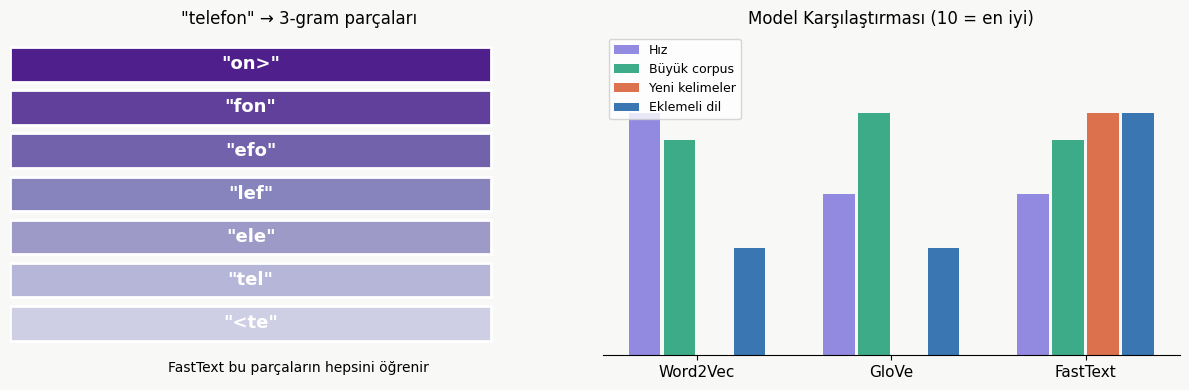

✅ Grafik kaydedildi: model_karsilastirma.png


In [ ]:
# N-gram karşılaştırma görseli
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#f8f8f6")

# Sol: FastText n-gram parçaları
ax = axes[0]
ax.set_facecolor("#f8f8f6")
kelime_ornek = "telefon"
ngrams = []
n = 3
padded = "<" + kelime_ornek + ">"
for i in range(len(padded) - n + 1):
    ngrams.append(padded[i:i+n])

renkler_ng = plt.cm.Purples(np.linspace(0.3, 0.9, len(ngrams)))
for i, (ng, renk) in enumerate(zip(ngrams, renkler_ng)):
    ax.barh(i, 1, color=renk, edgecolor="white", linewidth=2)
    ax.text(0.5, i, f'"{ng}"', va="center", ha="center", fontsize=13,
            fontweight="bold", color="white")

ax.set_xlim(0, 1.2)
ax.set_yticks([])
ax.set_title(f'"{kelime_ornek}" → 3-gram parçaları', fontsize=12)
ax.set_xlabel("FastText bu parçaların hepsini öğrenir")
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.set_xticks([])

# Sağ: Model karşılaştırma tablosu (bar chart)
ax2 = axes[1]
ax2.set_facecolor("#f8f8f6")

modeller = ["Word2Vec", "GloVe", "FastText"]
ozellikler = {
    "Hız":               [9, 6, 6],
    "Büyük corpus":      [8, 9, 8],
    "Yeni kelimeler":    [0, 0, 9],
    "Eklemeli dil":      [4, 4, 9],
}

x = np.arange(len(modeller))
genislik = 0.18
renkler_bar = ["#7F77DD", "#1D9E75", "#D85A30", "#185FA5"]

for i, (ozellik, skorlar) in enumerate(ozellikler.items()):
    offset = (i - 1.5) * genislik
    bars = ax2.bar(x + offset, skorlar, genislik * 0.9,
                   label=ozellik, color=renkler_bar[i], alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(modeller, fontsize=11)
ax2.set_yticks([])
ax2.set_ylim(0, 12)
ax2.set_title("Model Karşılaştırması (10 = en iyi)", fontsize=12)
ax2.legend(loc="upper left", fontsize=9)
ax2.spines[["top","right","left"]].set_visible(False)
ax2.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("model_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: model_karsilastirma.png")